The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- M1b. Weryfikacja modelu (Instrukcja, S=791) ---
Test 1 (Ruch w górę): OK
Test 2 (Rozciąganie): OK
Test 3 (Docisk opony): OK
WYNIK: PASSED


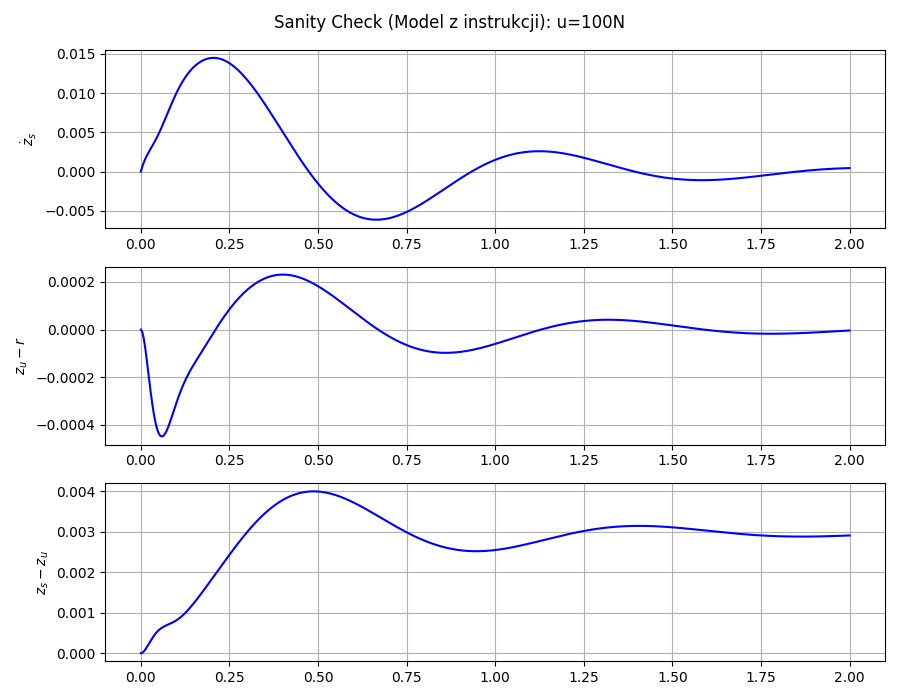

In [4]:

%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
from tesa_m1 import ActiveSuspension


MOJE_S = 791

# Inicjalizacja modelu
model = ActiveSuspension(MOJE_S)

#Uruchomienie weryfikacji (M1b)
t, y, status = model.run_sanity_check()

# Wyświetlenie wykresów
if status == "PASSED":
    model.plot_sanity_check(t, y)
else:
    print("Popraw błędy w modelu przed generowaniem wykresów!")

In [ ]:
from IPython.display import display, Markdown

m = model  # Upewnij się, że obiekt model jest zainicjowany

# Używamy podwójnych klamer {{ }} dla LaTeXa wewnątrz f-stringa
raport_m1_full = rf"""
## M1. Modelowanie (Pełny wektor zakłóceń)

### Definicja wejść i stanu
Zgodnie z pełną definicją z instrukcji, przyjęto wektor zakłóceń:
$$w = [r, \ \dot{{r}}, \ \ddot{{r}}]^T$$

Oraz wektor stanu z prędkością względną koła:
$$x = [z_s - z_u, \ \dot{{z}}_s, \ z_u - r, \ \dot{{z}}_u - \dot{{r}}]^T$$

### Równania macierzowe
Macierz dynamiki $A$ oraz macierz zakłóceń $E$ (dla $S={m.S}$) przyjmują postać:

**Macierz Dynamiki A:**
$$
A = \begin{{bmatrix}}
0 & 1 & 0 & -1 \\
-\frac{{k_s}}{{m_s}} & -\frac{{c_s}}{{m_s}} & 0 & \frac{{c_s}}{{m_s}} \\
0 & 0 & 0 & 1 \\
\frac{{k_s}}{{m_u}} & \frac{{c_s}}{{m_u}} & -\frac{{k_t}}{{m_u}} & -\frac{{c_s+c_t}}{{m_u}}
\end{{bmatrix}}
= \begin{{bmatrix}}
{m.A[0,0]:.0f} & {m.A[0,1]:.0f} & {m.A[0,2]:.0f} & {m.A[0,3]:.0f} \\
{m.A[1,0]:.2f} & {m.A[1,1]:.2f} & {m.A[1,2]:.2f} & {m.A[1,3]:.2f} \\
{m.A[2,0]:.0f} & {m.A[2,1]:.0f} & {m.A[2,2]:.0f} & {m.A[2,3]:.0f} \\
{m.A[3,0]:.2f} & {m.A[3,1]:.2f} & {m.A[3,2]:.2f} & {m.A[3,3]:.2f}
\end{{bmatrix}}
$$

**Macierz Zakłóceń E (dla $w=[r, \dot{{r}}, \ddot{{r}}]^T$):**
$$
E = \begin{{bmatrix}} 
0 & -1 & 0 \\ 
0 & \frac{{c_s}}{{m_s}} & 0 \\ 
0 & 0 & 0 \\ 
0 & -\frac{{c_s}}{{m_u}} & -1 
\end{{bmatrix}}
= \begin{{bmatrix}} 
0 & -1 & 0 \\ 
0 & {m.E[1,1]:.2f} & 0 \\ 
0 & 0 & 0 \\ 
0 & {m.E[3,1]:.2f} & -1 
\end{{bmatrix}}
$$
*Uwaga: Pierwsza kolumna macierzy E składa się z zer, ponieważ profil drogi $r$ jest uwzględniony bezpośrednio w definicji zmiennej stanu $x_3 = z_u - r$.*
"""

display(Markdown(raport_m1_full))


## M1. Modelowanie

### Definicja stanu
Zgodnie z instrukcją projektową, przyjęto wektor stanu:
$$x = [z_s - z_u, \ \dot{z}_s, \ z_u - r, \ \dot{z}_u - \dot{r}]^T$$
Ostatnia zmienna stanu to prędkość pionowa koła względem drogi.

### Równania macierzowe
Przyjmując wektor wejść zakłócających $w = [\dot{r}, \ddot{r}]^T$, macierze stanu prezentują się następująco dla $S=791$:

**Macierz A:**
$$
A = \begin{bmatrix}
0 & 1 & 0 & -1 \\
-\frac{k_s}{m_s} & -\frac{c_s}{m_s} & 0 & \frac{c_s}{m_s} \\
0 & 0 & 0 & 1 \\
\frac{k_s}{m_u} & \frac{c_s}{m_u} & -\frac{k_t}{m_u} & -\frac{c_s+c_t}{m_u}
\end{bmatrix}
= \begin{bmatrix}
0 & 1 & 0 & -1 \\
-56.71 & -5.00 & 0.00 & 5.00 \\
0 & 0 & 0 & 1 \\
453.66 & 40.00 & -2542.59 & -55.98
\end{bmatrix}
$$

**Macierz Zakłóceń E (dla $w=[\dot{r}, \ddot{r}]^T$):**
$$
E = \begin{bmatrix} -1 & 0 \\ \frac{c_s}{m_s} & 0 \\ 0 & 0 \\ -\frac{c_s}{m_u} & -1 \end{bmatrix}
= \begin{bmatrix} -1 & 0 \\ 5.00 & 0 \\ 0 & 0 \\ -40.00 & -1 \end{bmatrix}
$$
*Uwaga: Macierz E uwzględnia wpływ przyspieszenia drogi $\ddot{r}$ na dynamikę względną masy nieresorowanej.*
